# Thermocatalysis case study — VLM results explorer

Loads extracted performance/synthesis data for every VLM in `data/results_catalysis/`
plus the human ground truth, reuses the existing figure code in `catalysis_map.py`
(no plotting logic duplicated here), and reruns the human ground-truth eval to get
accuracy + detection metrics (RMSE, precision/recall/F1, FP/FN).

Style matches `icicle`'s `fig_*.ipynb` publication figures (Arial, boxed axes, `X90`
categorical palette) — see the style cell to swap palette/size.

## 0. Setup

`catalysis_map` holds `load_all_data` + `make_fig1..make_fig7`; we call those directly
instead of reimplementing plotting here. Its module-level `DATA_DIR`/`OUT_DIR` globals get
set per-VLM before each `make_figN` call, matching what its own `__main__` does.

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import sys
from pathlib import Path

REPO_ROOT = (
    Path.cwd().resolve().parents[2]
    if (Path.cwd() / "catalysis_map.py").exists() is False
    else Path.cwd()
)
# Fallback: locate repo root by walking up until 'src' exists
p = Path.cwd().resolve()
while not (p / "src").is_dir() and p != p.parent:
    p = p.parent
REPO_ROOT = p

SCRIPT_DIR = REPO_ROOT / "examples" / "scripts" / "case_study_thermocatalysis"
sys.path.insert(0, str(SCRIPT_DIR))
sys.path.insert(0, str(REPO_ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt

import catalysis_map as cm
import eval_vlm

DATA_ROOT = REPO_ROOT / "data" / "results_catalysis_string_match"
GT_DIR = REPO_ROOT / "data" / "results_catalysis_human"

VLMS = sorted(
    d.name
    for d in DATA_ROOT.iterdir()
    if d.is_dir() and (d / "figures").exists()
)
print("Found VLM result sets:", VLMS)

Found VLM result sets: ['claude-sonnet-4.6', 'deepseek-v3.2', 'gemini-3-flash', 'qwen3.5-397b-a17b']


In [6]:
# LLM-match judge scores (flat CSVs, not extraction trees -- load directly)
import pandas as pd

LLM_MATCH_DIR = REPO_ROOT / "data" / "results_catalysis_llm_match"
llm_match_dfs = {
    p.stem.replace("_llm_match", ""): pd.read_csv(p)
    for p in LLM_MATCH_DIR.glob("*_llm_match.csv")
}
for vlm, df in llm_match_dfs.items():
    print(vlm, df.shape)

llm_match_summary = pd.DataFrame(
    {
        vlm: {
            "n_rows": len(df),
            "mean_rmse": df["rmse"].mean(),
            "matched_series_rate": (
                df["n_matched_series"] / df["n_gt_series"]
            ).mean(),
        }
        for vlm, df in llm_match_dfs.items()
    }
).T
llm_match_summary

claude-sonnet-4.6 (160, 7)
gemini-3-flash (160, 7)
deepseek-v3.2 (23, 7)
qwen3.5-397b-a17b (160, 7)


,n_rows,mean_rmse,matched_series_rate
claude-sonnet-4.6,160.0,0.139666,0.703333
gemini-3-flash,160.0,0.048377,0.373333
deepseek-v3.2,23.0,NaN,0.000000
qwen3.5-397b-a17b,160.0,0.075634,0.583333


## 0b. Fix duplicate paper directories + drop non-image-capable VLM

Two papers exist under two differently-cased directory names per VLM
(`Lucentini_2019_catalytic` / `Lucentini2019Catalytic`, `yi_2018_plasma` / `Yi2018Plasma`).
These are **not** simple case duplicates — diffing the JSON contents shows they're two
separate extraction attempts with different amounts of populated `plot_data` (neither
variant is consistently better across VLMs). The GT directory only has the
capitalized/no-underscore name, so the other variant is invisible to eval as-is and was
silently inflating the plotting-only curve counts in section 2.

Fix: merge each pair per VLM into the canonical (GT-matching) name, keeping — per
material — whichever file actually has non-empty `plot_data`. Written to a scratch
directory so the original `data/results_catalysis/` is untouched.

`deepseek-v3.2` is dropped from the comparison: its OpenRouter endpoint has no image
input support (confirmed in `data/results_catalysis/deepseek-v3.2.log` — every figure
extraction 404'd), it only completed 3/26 papers before the run stopped, and its
synthesis blocks are byte-identical to the other VLMs' (synthesis is always extracted
via Gemini regardless of which VLM does plot extraction) — so it contributes nothing
unique and including it would just show a misleading 0-recall row.

In [7]:
import json
import shutil
import tempfile

_SKIP_FILES = {
    "linking_summary_llm.json",
    "linking_summary_human.json",
    "performance_mappings.json",
    "batch_summary.json",
    "summary.json",
}

# {vlm_dir_name: {underscored_variant: canonical_name}}
DUP_PAPER_DIRS = {
    "Lucentini_2019_catalytic": "Lucentini2019Catalytic",
    "yi_2018_plasma": "Yi2018Plasma",
}


def _has_plot_data(path: Path) -> bool:
    try:
        d = json.loads(path.read_text())
    except Exception:
        return False
    return bool((d.get("performance") or {}).get("plot_data"))


def merge_duplicate_papers(src_dir: Path, dst_dir: Path) -> None:
    """Copy src_dir -> dst_dir, merging DUP_PAPER_DIRS pairs into the canonical name.

    Per material, keeps whichever of the two variants has non-empty plot_data
    (falls back to the canonical variant's file if neither/both do).
    """
    if dst_dir.exists():
        shutil.rmtree(dst_dir)
    shutil.copytree(src_dir, dst_dir)

    for underscored, canonical in DUP_PAPER_DIRS.items():
        u_dir, c_dir = dst_dir / underscored, dst_dir / canonical
        if not u_dir.exists() or not c_dir.exists():
            continue
        for u_file in u_dir.glob("*.json"):
            if u_file.name in _SKIP_FILES:
                continue
            c_file = c_dir / u_file.name
            if (
                c_file.exists()
                and not _has_plot_data(c_file)
                and _has_plot_data(u_file)
            ):
                shutil.copy(u_file, c_file)
        shutil.rmtree(u_dir)  # canonical dir is now the single source of truth


SCRATCH_ROOT = Path(tempfile.mkdtemp(prefix="results_catalysis_merged_"))
MERGED_VLMS = [v for v in VLMS if v != "deepseek-v3.2"]

MERGED_DATA_ROOT = SCRATCH_ROOT / "results_catalysis"
for vlm in MERGED_VLMS:
    merge_duplicate_papers(DATA_ROOT / vlm, MERGED_DATA_ROOT / vlm)

print(f"Merged tree: {MERGED_DATA_ROOT}")
print(f"VLMs in comparison: {MERGED_VLMS}  (dropped: deepseek-v3.2)")

Merged tree: /var/folders/br/t_m09nrx5095w0jym2vqnbyr0000gp/T/results_catalysis_merged_65_zjc6z/results_catalysis
VLMs in comparison: ['claude-sonnet-4.6', 'gemini-3-flash', 'qwen3.5-397b-a17b']  (dropped: deepseek-v3.2)


In [8]:
paper_inventory = {
    name: sorted(
        d.name for d in path.iterdir() if d.is_dir() and d.name != "figures"
    )
    if path.is_dir()
    else []
    for name, path in {
        **{v: MERGED_DATA_ROOT / v for v in MERGED_VLMS},
        "human_gt": GT_DIR,
    }.items()
}

for name, papers in paper_inventory.items():
    print(f"{name}: {len(papers)} papers")
for name, papers in paper_inventory.items():
    print(f"\n{name} ({len(papers)}):")
    for p in papers:
        print(f"  {p}")

claude-sonnet-4.6: 25 papers
gemini-3-flash: 25 papers
qwen3.5-397b-a17b: 25 papers
human_gt: 28 papers

claude-sonnet-4.6 (25):
  01_Duan_2012_MCM
  02_Itoh_2002_Hydrogen
  03_Usman_2025_Rare
  04_Wu_2020_Ammonia
  05_Sayas_2020_High
  Chem2020Bimetallic
  Dasireddya_2021_ceo2
  Do2024Turning
  Fang2023Dispersed
  Hu2024Effects
  Lucentini2019Catalytic
  Maleki2024Co
  Meng_2024
  Okura2018Ammonia
  Podila2016Hydrogen
  Podila_2020
  Srifa_2016_cox
  Teng2024Ru
  Yi2018Plasma
  Yibo2023Plasma
  chen_2021_ru
  lorenzut_2012_femo
  varisli_2012_cox
  wu2021
  zhou2021

gemini-3-flash (25):
  01_Duan_2012_MCM
  02_Itoh_2002_Hydrogen
  03_Usman_2025_Rare
  04_Wu_2020_Ammonia
  05_Sayas_2020_High
  Chem2020Bimetallic
  Dasireddya_2021_ceo2
  Do2024Turning
  Fang2023Dispersed
  Hu2024Effects
  Lucentini2019Catalytic
  Maleki2024Co
  Meng_2024
  Okura2018Ammonia
  Podila2016Hydrogen
  Podila_2020
  Srifa_2016_cox
  Teng2024Ru
  Yi2018Plasma
  Yibo2023Plasma
  chen_2021_ru
  lorenzut_2012_fem

## 1. Style — pub-ready, matching `icicle`'s `fig_*.ipynb` notebooks

Typography/axes recipe ported from `icicle.utils.visualization.style` (Arial via
mathtext, all 4 spines, thicker axes/ticks) — reproduced inline since `pypalettes`
isn't a dependency of this repo. **Colors use this repo's own LeMat-Synth palette**
(`llm_synthesis.utils.style_utils.get_palette()`), not icicle's `X90` — only the
typography/layout was adapted from icicle, not its colors. Runs *after*
`catalysis_map`'s own `set_style("presentation")` (set at import time), so these
rcParams win for everything drawn below. Change `STYLE` and rerun to restyle.

In [9]:
import matplotlib as mpl

from llm_synthesis.utils.style_utils import get_palette

PALETTE = (
    get_palette()
)  # LeMat-Synth palette — the repo's own, not icicle's X90

FIGSIZE = {
    "default": (10, 6),
    "square": (2, 2),
    "square-mod": (2.5, 2),
    "wide": (12, 5),
    "tall": (6, 8),
}


def set_pub_style(style: str = "manuscript") -> None:
    """Port of icicle.utils.visualization.style.set_style (typography/axes only —
    color cycle below uses PALETTE, not icicle's X90)."""
    sz = {
        "manuscript": {
            "font": 10,
            "label": 10,
            "title": 10,
            "tick": 9,
            "legend": 9,
            "major_tick": 3,
        },
        "presentation": {
            "font": 12,
            "label": 12,
            "title": 12,
            "tick": 11,
            "legend": 11,
            "major_tick": 4,
        },
        "poster": {
            "font": 12,
            "label": 12,
            "title": 12,
            "tick": 11,
            "legend": 11,
            "major_tick": 4,
        },
    }[style]

    settings = {
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "mathtext.fontset": "custom",
        "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic",
        "mathtext.bf": "Arial:bold",
        "mathtext.sf": "Arial",
        "font.size": sz["font"],
        "axes.labelsize": sz["label"],
        "axes.titlesize": sz["title"],
        "xtick.labelsize": sz["tick"],
        "ytick.labelsize": sz["tick"],
        "legend.fontsize": sz["legend"],
        "legend.title_fontsize": sz["legend"],
        "figure.figsize": FIGSIZE["default"],
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "figure.facecolor": "white",
        "figure.autolayout": False,
        "axes.spines.top": True,
        "axes.spines.right": True,
        "axes.linewidth": 1.4,
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "axes.axisbelow": True,
        "axes.grid": False,
        "axes.xmargin": 0.02,
        "axes.ymargin": 0.02,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": sz["major_tick"],
        "ytick.major.size": sz["major_tick"],
        "xtick.major.width": 1.2,
        "ytick.major.width": 1.2,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,
        "xtick.minor.width": 0.5,
        "ytick.minor.width": 0.5,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        "xtick.top": False,
        "ytick.right": False,
        "xtick.color": "black",
        "ytick.color": "black",
        "lines.linewidth": 1.0,
        "lines.markersize": 4,
        "hatch.linewidth": 0.5,
        "grid.linewidth": 0.5,
        "legend.frameon": False,
        "legend.fancybox": False,
        "legend.facecolor": "none",
        "legend.edgecolor": "none",
        "legend.handlelength": 1.5,
        "legend.handletextpad": 0.4,
        "text.color": "black",
        "axes.prop_cycle": plt.cycler("color", PALETTE[:8]),
    }
    for k, v in settings.items():
        mpl.rcParams[k] = v


def save_fig(fig, name: str, output_dir="figures", dpi: int = 300) -> None:
    """Port of icicle.utils.visualization.style.save_fig — SVG + PNG, tight bbox."""
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    kwargs = dict(bbox_inches="tight", transparent=False)
    fig.savefig(out / f"{name}.svg", **kwargs)
    fig.savefig(out / f"{name}.png", dpi=dpi, **kwargs)


STYLE = "manuscript"  # "manuscript" | "presentation" | "poster"
SIZE = "square"  # "default" (10x6 rectangle) | "square" (8x8) — passed to make_figN below
set_pub_style(STYLE)
cm.PAL = PALETTE  # catalysis_map reads its categorical palette off this module global

PALETTE

['#E0A2D3',
 '#DFD6FB',
 '#448FF2',
 '#A7C8F2',
 '#F9CB9C',
 '#FCE5CD',
 '#FCEAF7',
 '#F2A8DD',
 '#D3D3D3',
 '#A9A9A9',
 '#808080',
 '#000000',
 '#7B5AEF',
 '#B27EDD']

## 2. Load extracted data per VLM + human ground truth

The human-annotated ground truth (`data/results_catalysis_human/`) is just another
results tree in the same `<paper_id>/<material>.json` shape `load_all_data` expects
(files are named `<material>_human.json` but that has no effect on parsing — files
have no `"material"` key either way, so `catalysis_map` falls back to the filename
stem regardless). It has no `"synthesis"` key at all, so `df_synthesis` for GT is
sparse (metal/support parsed from the name, no real synthesis steps) — figures 3-5
still render, just less informative for GT than for VLM output.

In [10]:
SOURCES = {
    **{vlm: MERGED_DATA_ROOT / vlm for vlm in MERGED_VLMS},
    "human_gt": GT_DIR,
}

data = {}
for name, path in SOURCES.items():
    cm.DATA_DIR = path
    df_curves, df_synthesis = cm.load_all_data(DATA_DIR=cm.DATA_DIR)
    data[name] = {"curves": df_curves, "synthesis": df_synthesis}
    print(
        f"{name:<20} curves={len(df_curves):<5} synthesis={len(df_synthesis)}"
    )

claude-sonnet-4.6    curves=200   synthesis=264
gemini-3-flash       curves=108   synthesis=264
qwen3.5-397b-a17b    curves=148   synthesis=264
human_gt             curves=157   synthesis=170


## 3. Figures — pick a source, render its 8 figures inline

Reuses `make_fig1`..`make_fig7` (+ the fig5a/5b split) from `catalysis_map.py`
verbatim. fig1/6/7 are now three colorings (metal / synthesis strategy / support) of
the *same* conversion-landscape line-chart template — no more marker-shape overload
on fig1, no more 3D on fig7 — so they read as one figure family. fig5 is now two
separate figures (promoter effect, synthesis conditions → performance) instead of one
two-panel figure. Each call both saves PNG/PDF (VLMs → `<vlm>/figures/`; GT →
`results_catalysis_human/figures/`) and returns the `Figure`, which renders inline.
Change `SOURCE_TO_PLOT` / `SIZE` (set in the style cell) and rerun to switch.

Rendering figures for: qwen3.5-397b-a17b (size=square)
  ✓ Landscape (color_by=metal) saved (140 curves, 17 metal categories)
  ✓ Figure 2 saved (14 metals × 12 supports)
  ✓ Figure 3 saved (16 actions, 102 transitions)
  ✓ Figure 4 saved (top 6 catalysts)
  ✓ Figure 5a saved (9 promoter pairs auto-detected)
  ✓ Figure 5b saved (43 materials)
  ✓ Landscape (color_by=synthesis) saved (140 curves, 7 synthesis categories)
  ✓ Landscape (color_by=support) saved (123 curves, 13 support categories)


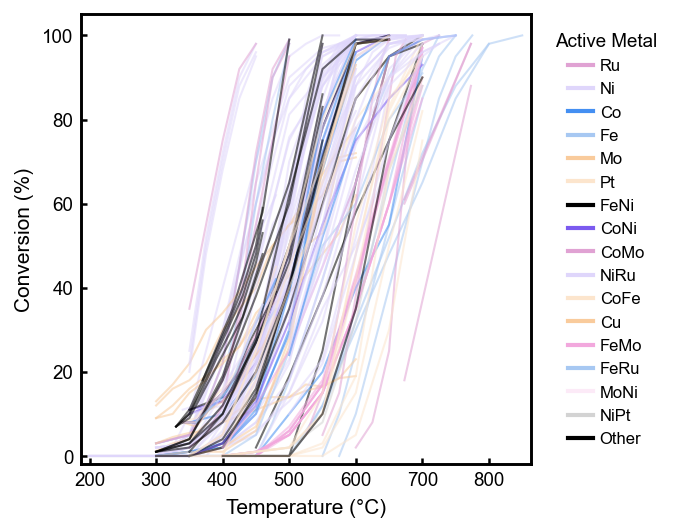

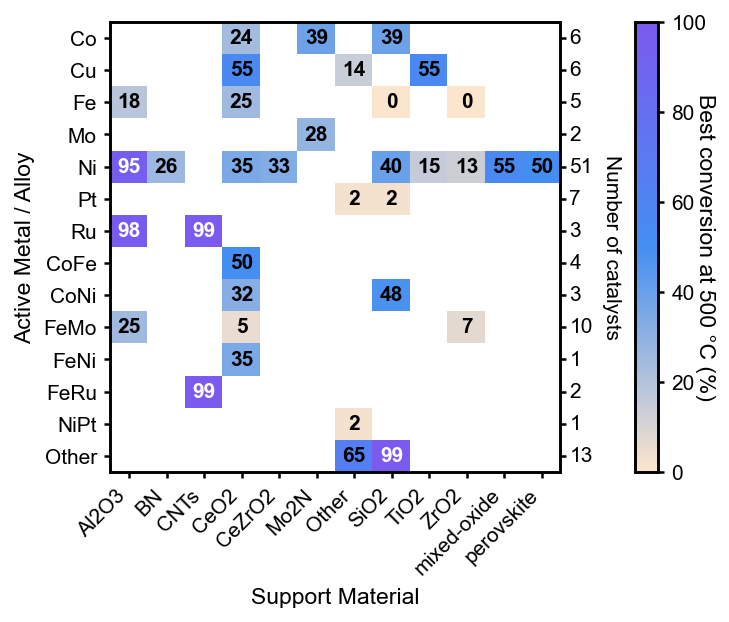

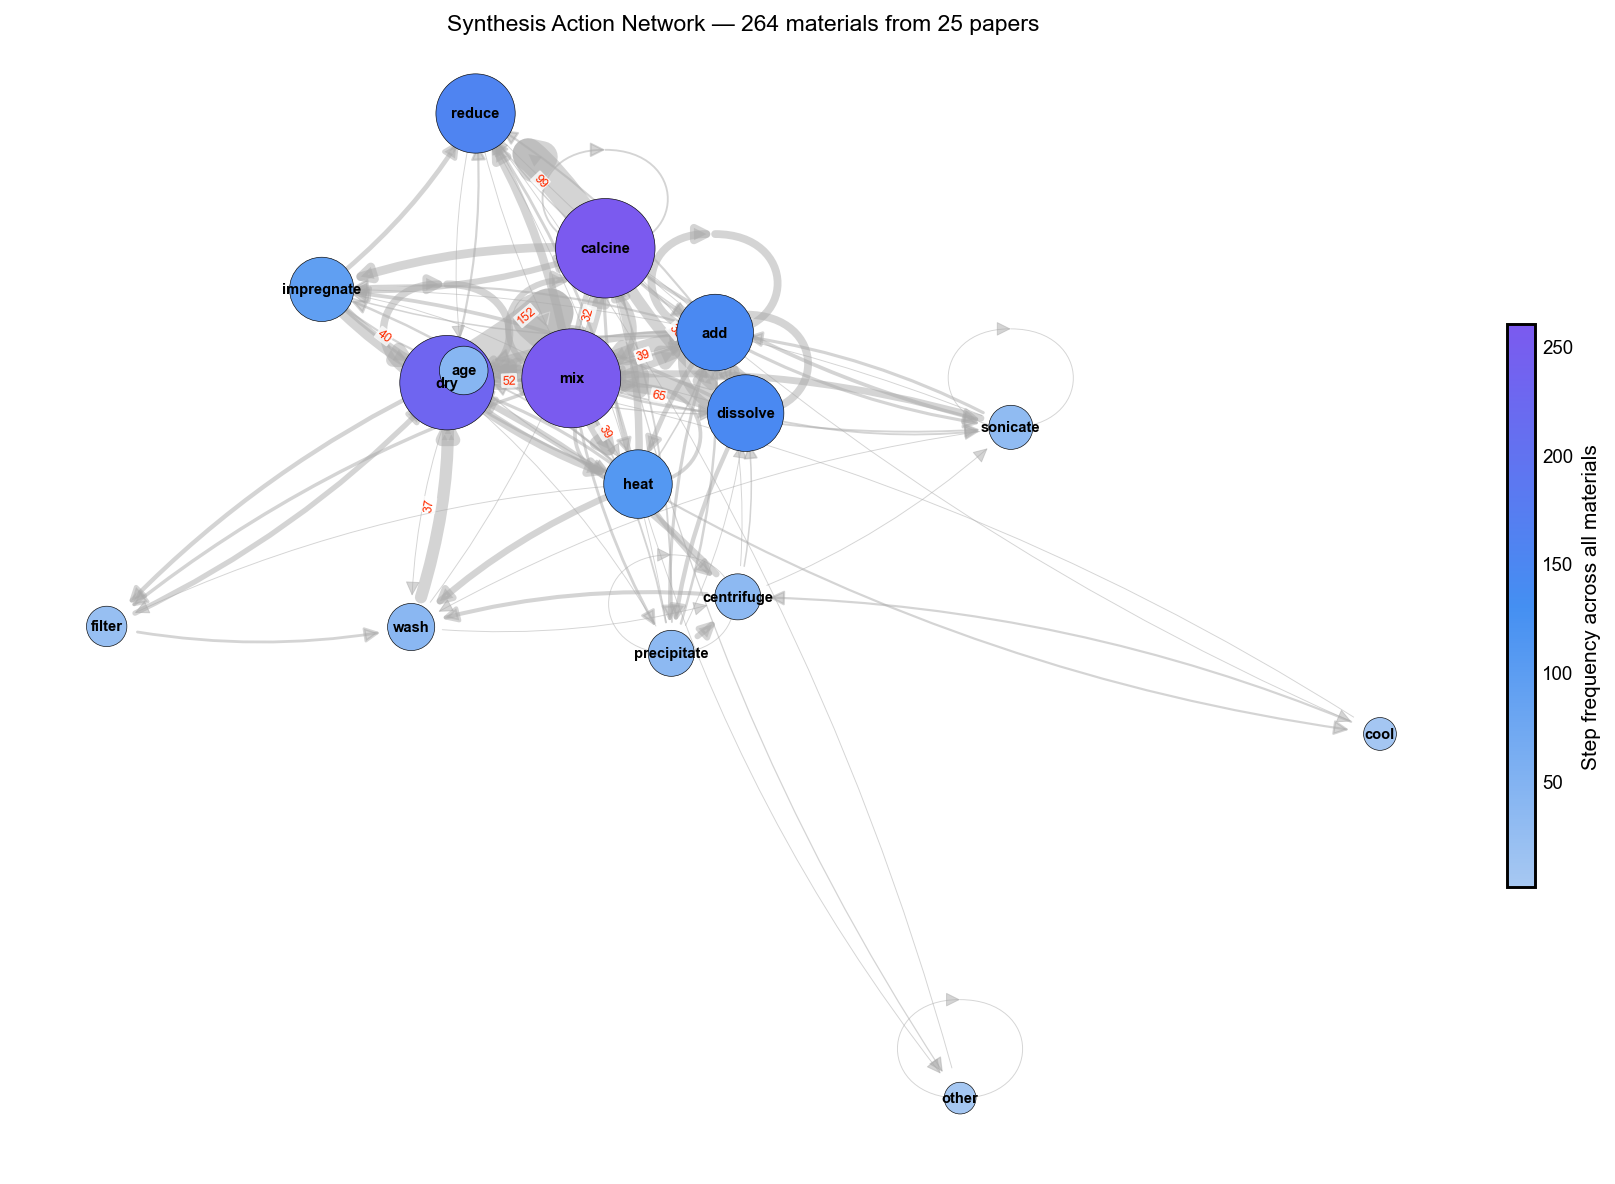

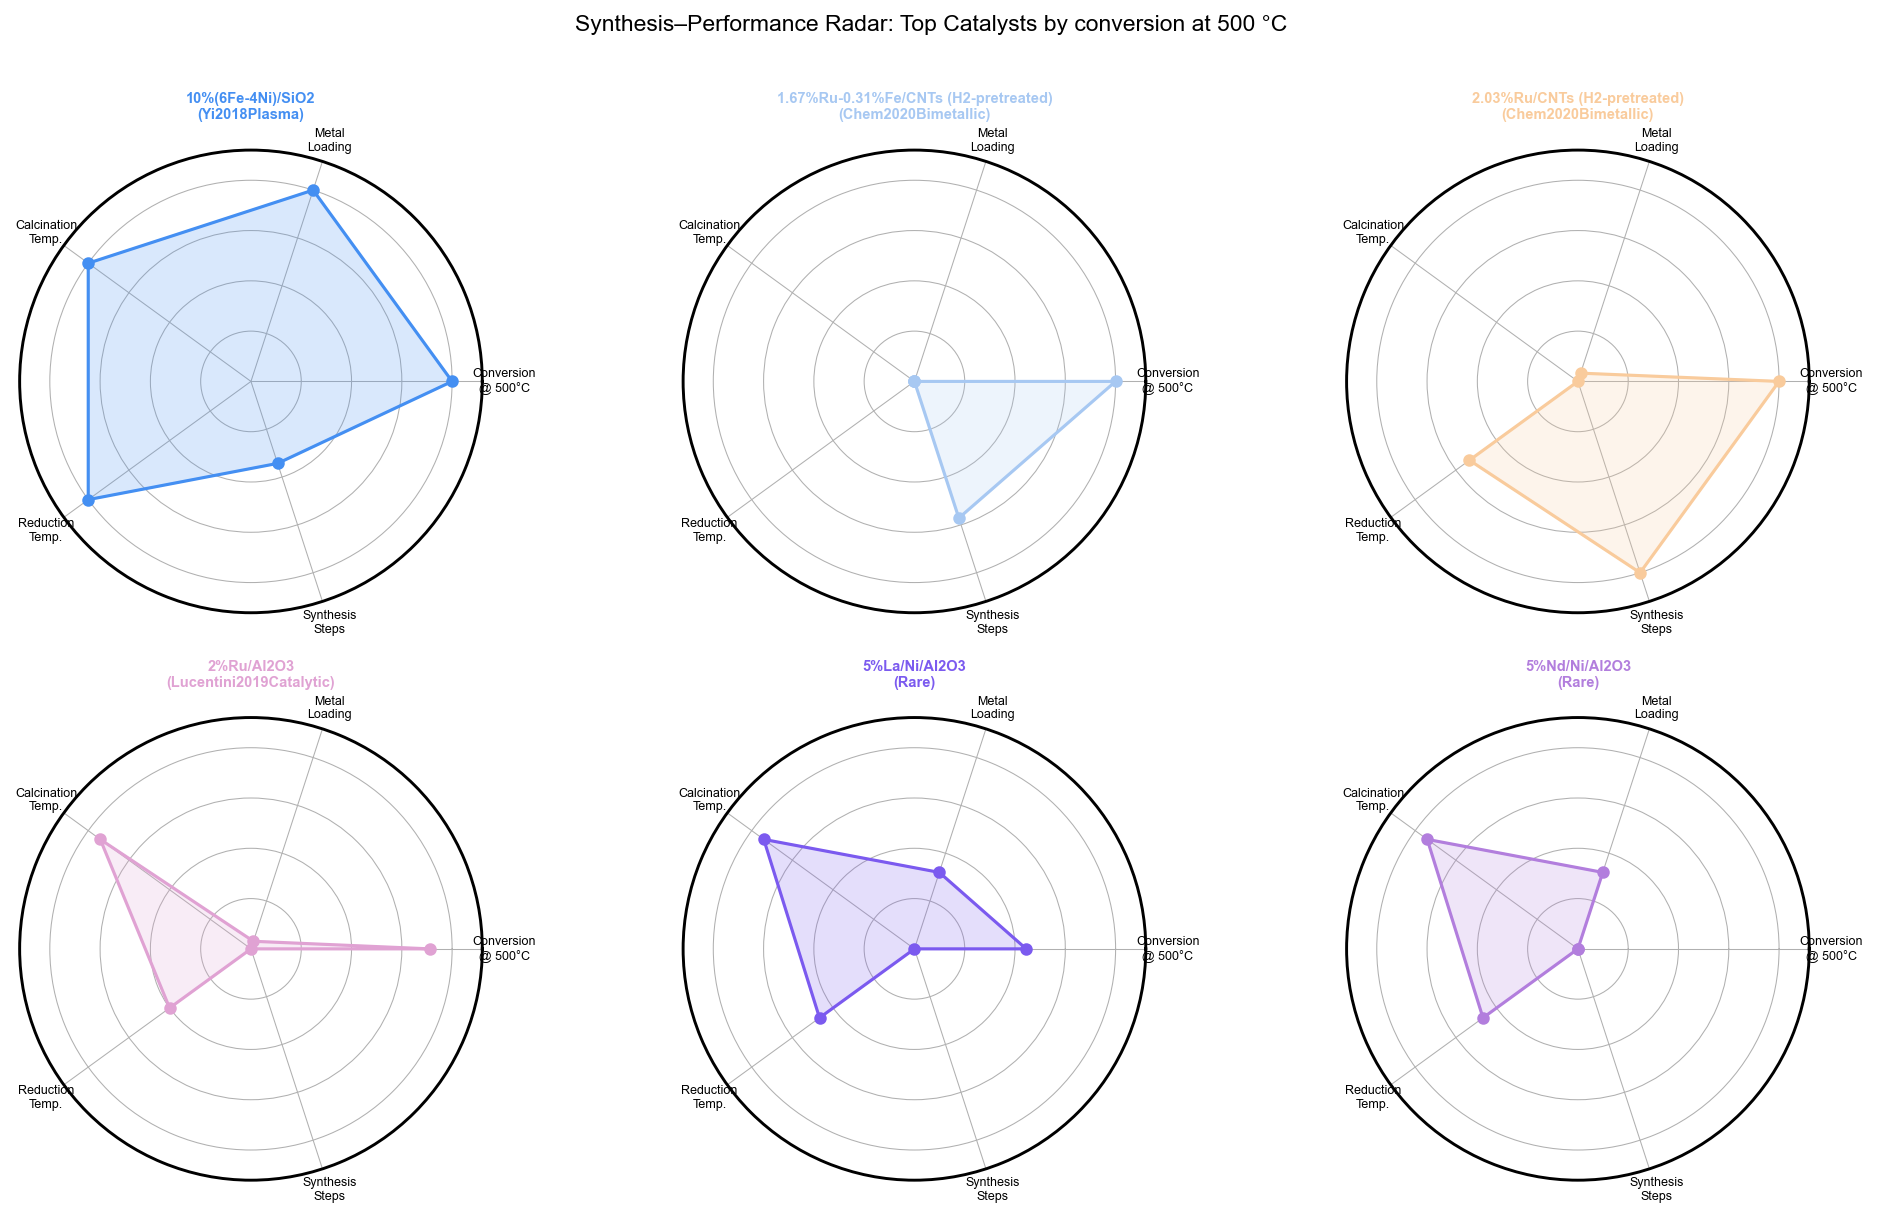

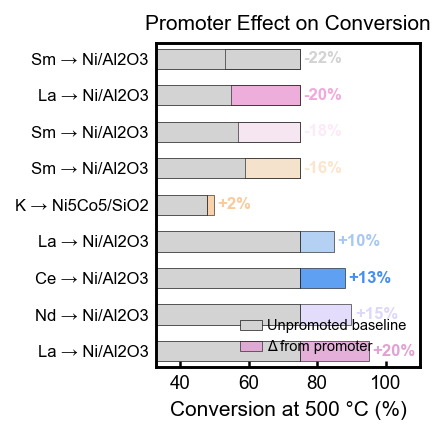

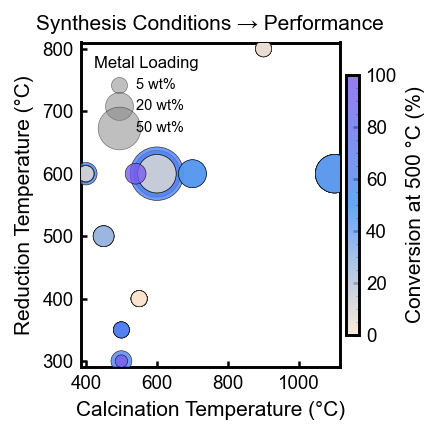

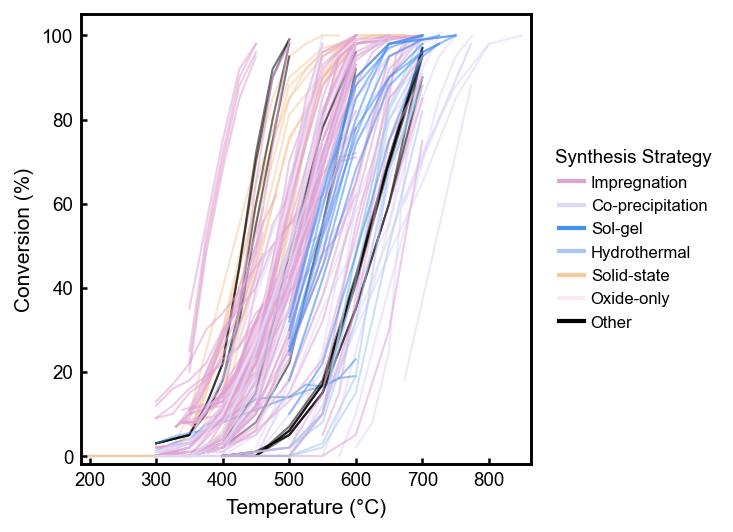

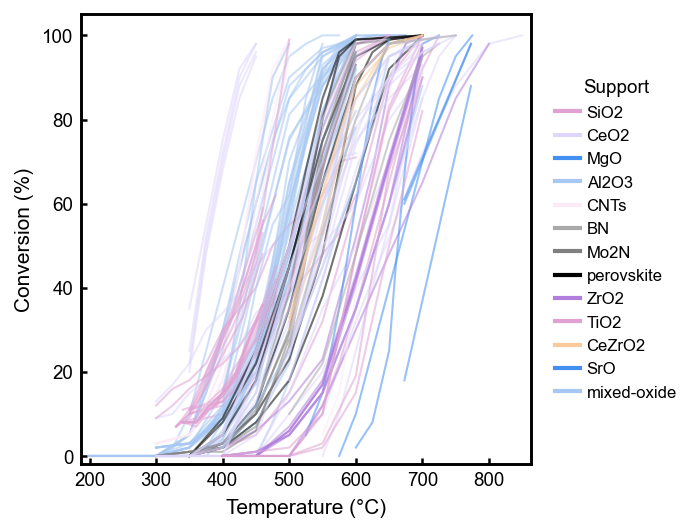

In [110]:
SOURCE_TO_PLOT = "qwen3.5-397b-a17b"  # any key from SOURCES, e.g. "qwen3.5-397b-a17b" or "human_gt"

cm.DATA_DIR = SOURCES[SOURCE_TO_PLOT]
cm.OUT_DIR = SCRIPT_DIR / "figures" / SOURCE_TO_PLOT
cm.OUT_DIR.mkdir(parents=True, exist_ok=True)
df_curves = data[SOURCE_TO_PLOT]["curves"]
df_synthesis = data[SOURCE_TO_PLOT]["synthesis"]

print(f"Rendering figures for: {SOURCE_TO_PLOT} (size={SIZE})")
fig1 = cm.make_fig1(df_curves, size=SIZE)  # landscape, color by metal
fig2 = cm.make_fig2(df_curves)  # metal x support heatmap
fig3 = cm.make_fig3(df_synthesis)  # synthesis network
fig4 = cm.make_fig4(df_curves, df_synthesis)  # radar charts
fig5a = cm.make_fig5a_promoter(df_curves, size=SIZE)  # promoter effect
fig5b = cm.make_fig5b_conditions(
    df_curves, df_synthesis, size=SIZE
)  # conditions -> performance
fig6 = cm.make_fig6(
    df_curves, size=SIZE
)  # landscape, color by synthesis strategy
fig7 = cm.make_fig7(df_curves, size=SIZE)  # landscape, color by support

## 3b. Metal x Temperature heatmap + zoom into one metal

Two more figures, same idea as the storyboard: `fig2b` is Figure 1's landscape
"collapsed" along temperature into a metal x temperature-bin heatmap (median
conversion per bin) — same relationship Figure 2 already has to Figure 1, just
binning by temperature instead of by support. `metal_zoom` re-uses the same
landscape-figure code as fig1/6/7 but pre-filtered to one metal and colored by
synthesis strategy, so within-metal variation (by promoter/support/synthesis route)
is readable. Change `ZOOM_METAL` to zoom into a different metal.

  ✓ Figure 2b saved (17 metals 11 temp bins)


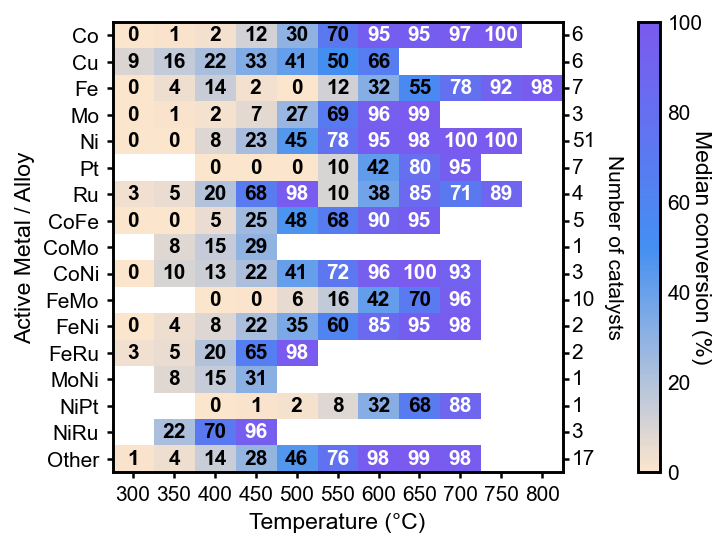

In [106]:
import numpy as np

_all_temps = np.concatenate(
    [np.array(c, dtype=float)[:, 0] for c in df_curves["coordinates"]]
)
_lo, _hi = 25 * round(_all_temps.min() / 25), 25 * round(_all_temps.max() / 25)
_exclude = (100, 150, 200, 250, 850)
temp_bins = [t for t in np.arange(_lo, _hi + 1, 50) if t not in _exclude]

fig2b = cm.make_fig2b_metal_temp_heatmap(
    df_curves, temp_bins=temp_bins, size="square"
)

In [13]:
LIST_OF_METALS = sorted(
    set(
        m
        for metals in df_curves["metal"].dropna().str.split(",")
        for m in metals
    )
)
LIST_OF_METALS

['Co',
 'CoFe',
 'CoMo',
 'CoNi',
 'Cu',
 'Fe',
 'FeMo',
 'FeNi',
 'FeRu',
 'Mo',
 'MoNi',
 'Ni',
 'NiPt',
 'NiRu',
 'Other',
 'Pt',
 'Ru']

  ✓ Metal zoom saved (metal=Ni, color_by=synthesis_strategy, 53 curves)


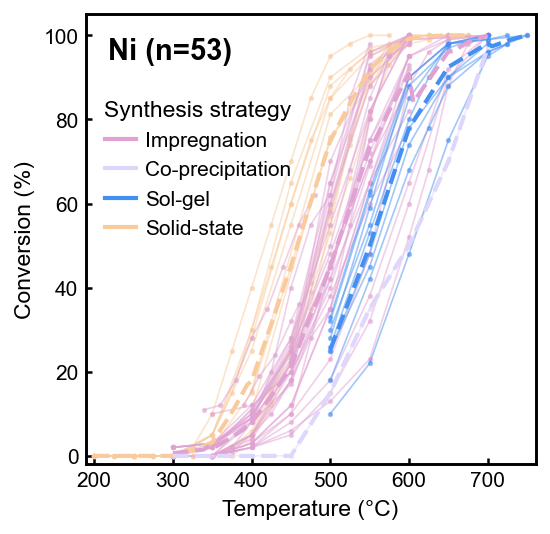

In [56]:
LIST_OF_METALS = ['Ni']
set_pub_style(
    STYLE
)  # autoreload can re-trigger catalysis_map's own set_style("presentation") on import, which resets spines/linewidth -- reapply ours before this loop
for metal in LIST_OF_METALS:
    fig_zoom_strategy = cm.make_metal_zoom_fig(
        df_curves, metal, size=SIZE, color_by="synthesis_strategy"
    )

  ✓ Metal zoom saved (metal=Ni, color_by=synthesis_strategy, 53 curves)
  ✓ Metal zoom saved (metal=Ni, color_by=support, 53 curves)


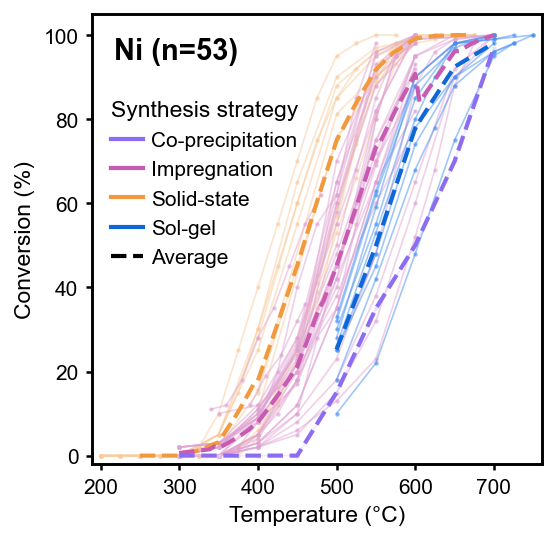

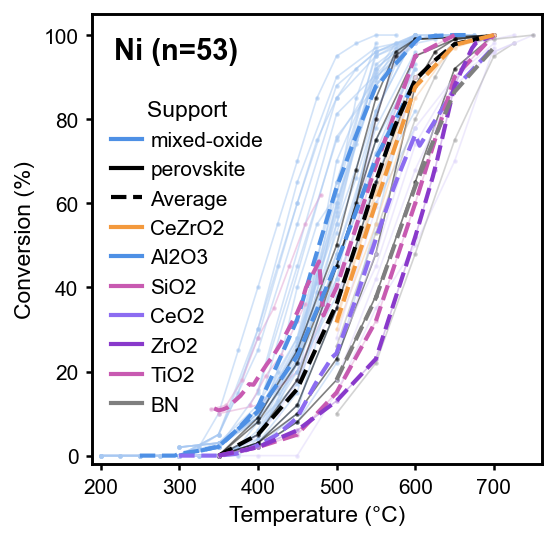

In [108]:
ZOOM_METAL = "Ni"  # change to zoom into a different metal's curves

set_pub_style(STYLE)  # same reload-safety as the loop above
fig_zoom_strategy = cm.make_metal_zoom_fig(
    df_curves, ZOOM_METAL, size=SIZE, color_by="synthesis_strategy"
)
fig_zoom_support = cm.make_metal_zoom_fig(
    df_curves, ZOOM_METAL, size=SIZE, color_by="support"
)

## 4. Ground-truth eval — accuracy (RMSE/MAE) per VLM

Builds `df_eval` from the pre-computed LLM-judge match CSVs (`results_catalysis_llm_match/`,
section 0) rather than re-running `eval_vlm.evaluate()`'s plain string matcher — the LLM
judge tolerates paraphrased material names, so it matches substantially more series
(see section 7 caveat).

In [16]:
# Uses the pre-computed LLM-match CSVs (paraphrase-tolerant name matching, loaded as
# llm_match_dfs in section 0) instead of eval_vlm.evaluate()'s plain string matcher --
# the string matcher misses far more series (see caveat below), understating VLMs like
# qwen whose material names often need paraphrase-tolerant matching to line up with GT.
# deepseek-v3.2 stays excluded, same reasoning as section 0b (no image input support).
METRIC = "rmse"  # llm_match CSVs only carry rmse

eval_rows = []
for vlm in MERGED_VLMS:
    df = llm_match_dfs[vlm].rename(columns={METRIC: "score"}).copy()
    df["vlm"] = vlm
    eval_rows.append(df)

df_eval = pd.concat(eval_rows, ignore_index=True)
df_eval.head()

,paper_id,material_gt,material_llm,score,n_gt_series,n_llm_series,n_matched_series,vlm
0,01_Duan_2012_MCM,Co3Mo7_MCM-41,5pctCo3Mo7_MCM-41,NaN,1.0,0.0,0.0,claude-sonnet-4.6
1,01_Duan_2012_MCM,Co5Mo5_MCM-41,5pctCo5Mo5_MCM-41,NaN,1.0,0.0,0.0,claude-sonnet-4.6
2,01_Duan_2012_MCM,Co6Mo4_MCM-41,5pctCo6Mo4_MCM-41,NaN,1.0,0.0,0.0,claude-sonnet-4.6
3,01_Duan_2012_MCM,Co7Mo3_MCM-41,5pctCo7Mo3_MCM-41,NaN,1.0,2.0,1.0,claude-sonnet-4.6
4,01_Duan_2012_MCM,Co7Mo3_SiO2,5pctCo7Mo3_SiO2,NaN,1.0,1.0,0.0,claude-sonnet-4.6


In [17]:
summary = (
    df_eval.dropna(subset=["score"])
    .groupby("vlm")["score"]
    .agg(mean="mean", median="median", n_scored="count")
    .join(df_eval.groupby("vlm").size().rename("n_total"))
)
summary["n_missing"] = summary["n_total"] - summary["n_scored"]
summary.sort_values("mean")

,mean,median,n_scored,n_total,n_missing
vlm,,,,,
gemini-3-flash,0.048377,0.006988,41,160,119
qwen3.5-397b-a17b,0.075634,0.052360,68,160,92
claude-sonnet-4.6,0.139666,0.112446,65,160,95


## 5. Detection metrics — precision / recall / F1 / FP / FN

`n_gt_series`/`n_llm_series`/`n_matched_series` in `df_eval` give series-level counts per
material. Aggregated per VLM:

- **TP** = matched series
- **FN** = GT series never matched (missed extractions, including whole materials with no LLM match at all)
- **FP** = LLM series that don't correspond to any GT series (hallucinated/misnamed curves)

In [18]:
def detection_metrics(df_eval: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for vlm, g in df_eval.groupby("vlm"):
        tp = fp = fn = 0
        no_match_materials = 0
        for _, r in g.iterrows():
            if pd.isna(r["material_llm"]):
                no_match_materials += 1
                continue
            gt_n = int(r["n_gt_series"] or 0)
            llm_n = int(r["n_llm_series"] or 0)
            matched = int(r["n_matched_series"] or 0)
            tp += matched
            fn += gt_n - matched
            fp += llm_n - matched
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall)
            else 0.0
        )
        rows.append(
            {
                "vlm": vlm,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "materials_no_match": no_match_materials,
                "materials_total": len(g),
            }
        )
    return (
        pd.DataFrame(rows).set_index("vlm").sort_values("f1", ascending=False)
    )


df_detection = detection_metrics(df_eval)
df_detection

,tp,fp,fn,precision,recall,f1,materials_no_match,materials_total
vlm,,,,,,,,
claude-sonnet-4.6,107,53,45,0.668750,0.703947,0.685897,10,160
qwen3.5-397b-a17b,89,20,63,0.816514,0.585526,0.681992,10,160
gemini-3-flash,57,18,95,0.760000,0.375000,0.502203,10,160


## 6. Combined leaderboard

In [19]:
leaderboard = summary.join(df_detection)
leaderboard = leaderboard[
    [
        "mean",
        "n_scored",
        "n_missing",
        "tp",
        "fp",
        "fn",
        "precision",
        "recall",
        "f1",
    ]
]
leaderboard.rename(columns={"mean": f"mean_{METRIC}"}).sort_values(
    "f1", ascending=False
)

,mean_rmse,n_scored,n_missing,tp,fp,fn,precision,recall,f1
vlm,,,,,,,,,
claude-sonnet-4.6,0.139666,65,95,107,53,45,0.668750,0.703947,0.685897
qwen3.5-397b-a17b,0.075634,68,92,89,20,63,0.816514,0.585526,0.681992
gemini-3-flash,0.048377,41,119,57,18,95,0.760000,0.375000,0.502203


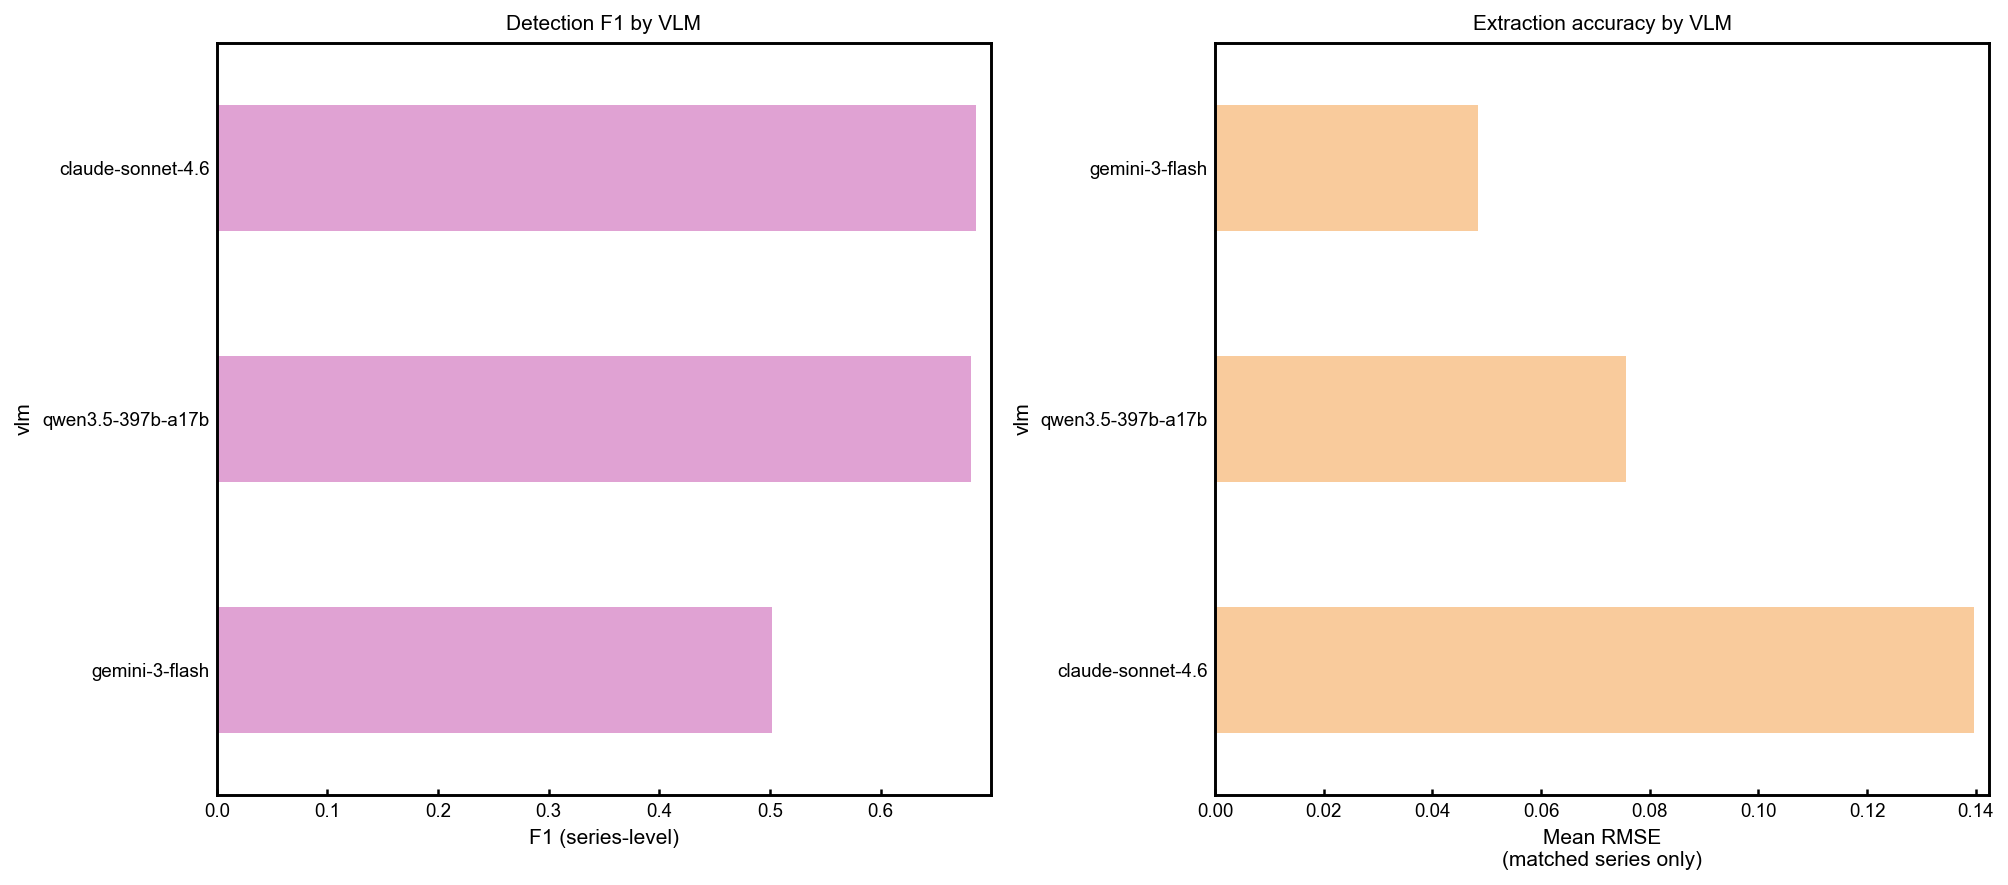

In [20]:
fig, axes = plt.subplots(
    1, 2, figsize=(FIGSIZE["wide"][0] + 1.5, FIGSIZE["default"][1])
)

df_detection["f1"].sort_values().plot.barh(ax=axes[0], color=PALETTE[0])
axes[0].set_xlabel("F1 (series-level)")
axes[0].set_title("Detection F1 by VLM")

summary["mean"].sort_values(ascending=False).plot.barh(
    ax=axes[1], color=PALETTE[4]
)
axes[1].set_xlabel(f"Mean {METRIC.upper()}\n(matched series only)")
axes[1].set_title("Extraction accuracy by VLM")

fig.tight_layout()
save_fig(fig, "vlm_leaderboard", output_dir=SCRIPT_DIR / "figures")

## 7. Caveat

Sections 4-6 now use the LLM-judge name matcher (`results_catalysis_llm_match/`,
paraphrase-tolerant) instead of `eval_vlm`'s plain string matcher, so `materials_no_match`
above reflects real missing/hallucinated extractions rather than matcher limitations.
`deepseek-v3.2` is excluded throughout (see section 0b: no image input support, 3/26
papers completed).